# 04 Whisper 无归一化 Transformer 情感分类训练

围绕毕设主线训练 Whisper 无归一化 Transformer 情感模型，并统一支持三种训练模式：

- `live_encoder`：直接输入音频，训练 `Whisper Encoder -> Emotion Head`
- `cached_sequence`：预缓存序列特征 `(T, D)`，仅训练情感头
- `cached_pooled`：预缓存 pooled 特征，仅用于 `legacy_mlp` 兼容基线

模型结构、归一化、池化方式、冻结策略与 checkpoint 格式统一由 `configs/config.yaml` 中的 `shared_model` 配置控制。

本 notebook 现在同时支持两类对比：

- 跨架构对比：`CNN+BiLSTM+Attention` vs `Whisper+Norm-Free Transformer`
- 主线内部消融：`Derf / DyT / LayerNorm`，以及 `freeze_all / unfreeze_last_2`


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/identifier'
    os.chdir(PROJECT_ROOT)
    !pip install -q openai-whisper noisereduce librosa soundfile pyyaml
else:
    # 自动查找项目根目录（兼容从任意目录启动 Jupyter）
    for _candidate in [os.path.abspath('..'), os.path.abspath('.'), os.path.expanduser('~/identifier')]:
        if os.path.isfile(os.path.join(_candidate, 'configs', 'config.yaml')):
            PROJECT_ROOT = _candidate
            break
    else:
        raise RuntimeError('找不到项目根目录，请确认 configs/config.yaml 存在')
    os.chdir(PROJECT_ROOT)

print(f'项目根目录: {os.getcwd()}')

项目根目录: /root/Emotion-perception-driven-speech-recognition-system


In [ ]:
import sys
import time
import copy
import math
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import whisper
import matplotlib.pyplot as plt

sys.path.insert(0, PROJECT_ROOT)
from utils.audio_utils import load_config, EMOTION_LABELS, LABEL2ID
from utils.losses import FocalLoss
from utils.split_utils import speaker_group_split, infer_subset_from_path
from preprocessing.whisper_feature_cache import (
    build_sample_list,
    prepare_whisper_training_data,
    build_whisper_mel_batch,
    collate_whisper_audio_batch,
    TRAINING_MODE_LIVE_ENCODER,
    TRAINING_MODE_CACHED_SEQUENCE,
    TRAINING_MODE_CACHED_POOLED,
)
from models.whisper_emotion import (
    WhisperEmotionHead,
    build_shared_model_from_config,
    create_shared_checkpoint,
    DEFAULT_SHARED_MODEL_CONFIG,
)

cfg = load_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')

seed = int(cfg['training'].get('seed', 42))
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

def get_training_value(key, default=None, mode=None):
    mode = mode or training_mode
    training_cfg = cfg.get('training', {})
    mode_key = f'{mode}_{key}'
    if mode_key in training_cfg:
        return training_cfg[mode_key]
    return training_cfg.get(key, default)


shared_cfg = dict(DEFAULT_SHARED_MODEL_CONFIG)
shared_cfg.update(cfg.get('shared_model', {}))
training_mode = str(shared_cfg.get('training_mode', TRAINING_MODE_LIVE_ENCODER)).strip().lower()
variant = str(shared_cfg.get('variant', 'transformer_head')).strip().lower()
shared_cfg['dropout'] = float(get_training_value('dropout', shared_cfg.get('dropout', 0.1), training_mode))
whisper_size = cfg['model']['whisper_size']
num_classes = int(cfg['emotion']['num_classes'])

print('共享模型配置:')
print({
    'variant': variant,
    'training_mode': training_mode,
    'pooling': shared_cfg.get('pooling'),
    'norm': shared_cfg.get('norm'),
    'freeze_strategy': shared_cfg.get('freeze_strategy'),
    'head_layers': shared_cfg.get('head_layers'),
    'head_hidden_dim': shared_cfg.get('head_hidden_dim'),
    'num_heads': shared_cfg.get('num_heads'),
    'ff_mult': shared_cfg.get('ff_mult'),
})


## 1. 准备数据集

In [ ]:
feature_bs = int(cfg.get('training', {}).get('whisper_feature_batch_size', 8))
feature_workers = int(cfg.get('training', {}).get('whisper_feature_num_workers', 0))
feature_prefetch = int(cfg.get('training', {}).get('whisper_feature_prefetch_factor', 2))
cache_dtype = str(shared_cfg.get('cache_feature_dtype', 'float16'))
subsets = ('ravdess', 'casia', 'tess', 'esd', 'emodb', 'iemocap')

dataset, meta = prepare_whisper_training_data(
    cfg=cfg,
    device=device,
    subsets=subsets,
    batch_size=feature_bs,
    feature_dtype=cache_dtype,
    overwrite=False,
    num_workers=feature_workers,
    prefetch_factor=feature_prefetch,
)
print(f'训练数据元信息: {meta}')

sample_list = build_sample_list(cfg['paths']['processed_data'], LABEL2ID, subsets=subsets)
if len(sample_list) != len(dataset):
    raise RuntimeError(
        f'样本列表与 dataset 长度不一致: samples={len(sample_list)} dataset={len(dataset)}'
    )

sample_paths = [wav_path for wav_path, _ in sample_list]
sample_labels = np.asarray([label for _, label in sample_list], dtype=np.int64)
train_ratio = float(cfg['training']['train_ratio'])
val_ratio = float(cfg['training']['val_ratio'])
test_ratio = float(cfg['training']['test_ratio'])

train_indices, val_indices, test_indices, split_meta = speaker_group_split(
    sample_paths,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    seed=seed,
)

train_set = Subset(dataset, train_indices)
val_set = Subset(dataset, val_indices)
test_set = Subset(dataset, test_indices)
train_n = len(train_set)
val_n = len(val_set)
test_n = len(test_set)

train_sample_paths = [sample_paths[i] for i in train_indices]
train_sample_labels = sample_labels[train_indices]
train_sample_subsets = [infer_subset_from_path(path) for path in train_sample_paths]
raw_train_class_counts = np.bincount(train_sample_labels, minlength=num_classes).astype(np.int64)

esd_epoch_cap = int(get_training_value('esd_epoch_cap', 10000, training_mode))
if esd_epoch_cap <= 0:
    esd_epoch_cap = len(train_sample_paths)

train_esd_relative_indices = np.asarray(
    [idx for idx, subset in enumerate(train_sample_subsets) if subset == 'esd'],
    dtype=np.int64,
)
train_non_esd_relative_indices = np.asarray(
    [idx for idx, subset in enumerate(train_sample_subsets) if subset != 'esd'],
    dtype=np.int64,
)
raw_esd_train_samples = int(len(train_esd_relative_indices))
raw_non_esd_train_samples = int(len(train_non_esd_relative_indices))

def compute_virtual_capped_class_counts(labels, subsets, num_classes, esd_epoch_cap):
    labels = np.asarray(labels, dtype=np.int64)
    subsets = np.asarray(list(subsets), dtype=object)
    non_esd_mask = subsets != 'esd'
    esd_mask = ~non_esd_mask

    counts = np.bincount(labels[non_esd_mask], minlength=num_classes).astype(np.float64)
    esd_counts = np.bincount(labels[esd_mask], minlength=num_classes).astype(np.float64)

    raw_esd_total = int(esd_mask.sum())
    if raw_esd_total == 0 or raw_esd_total <= esd_epoch_cap:
        esd_scale = 1.0
        effective_esd_samples = raw_esd_total
    else:
        esd_scale = float(esd_epoch_cap) / float(raw_esd_total)
        effective_esd_samples = int(esd_epoch_cap)

    counts += esd_counts * esd_scale
    return counts, {
        'raw_esd_train_samples': raw_esd_total,
        'raw_non_esd_train_samples': int(non_esd_mask.sum()),
        'effective_esd_samples_per_epoch': effective_esd_samples,
        'effective_train_samples_per_epoch': int(non_esd_mask.sum()) + effective_esd_samples,
        'esd_scale': float(esd_scale),
    }


def compute_class_weights(class_counts, num_classes):
    class_counts = np.asarray(class_counts, dtype=np.float64)
    clipped = np.maximum(class_counts, 1e-6)
    weights = 1.0 / clipped
    weights = weights / weights.sum() * num_classes
    return weights.astype(np.float32)


virtual_train_class_counts, train_sampling_meta = compute_virtual_capped_class_counts(
    train_sample_labels,
    train_sample_subsets,
    num_classes,
    esd_epoch_cap,
)
class_weights = compute_class_weights(virtual_train_class_counts, num_classes)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)


def build_epoch_train_relative_indices(epoch, seed, esd_epoch_cap):
    if raw_esd_train_samples == 0 or raw_esd_train_samples <= esd_epoch_cap:
        selected_esd = train_esd_relative_indices.copy()
    else:
        esd_rng = np.random.default_rng(int(seed) + int(epoch))
        selected_esd = np.sort(
            esd_rng.choice(train_esd_relative_indices, size=esd_epoch_cap, replace=False)
        )

    combined = np.concatenate([train_non_esd_relative_indices, selected_esd]).astype(np.int64, copy=False)
    shuffle_rng = np.random.default_rng(int(seed) * 1009 + int(epoch))
    shuffled = shuffle_rng.permutation(combined)
    return shuffled.tolist(), {
        'effective_esd_samples': int(len(selected_esd)),
        'effective_train_samples': int(len(shuffled)),
    }


def build_epoch_train_loader(epoch):
    effective_indices, epoch_sampling = build_epoch_train_relative_indices(epoch, seed, esd_epoch_cap)
    effective_train_set = Subset(train_set, effective_indices)
    loader = DataLoader(effective_train_set, shuffle=False, **train_loader_kwargs)
    return loader, epoch_sampling


base_batch_size = int(cfg['training']['batch_size'])
default_live_train_batch_size = min(base_batch_size, 16 if device.type == 'cuda' else 8)
default_live_eval_batch_size = min(base_batch_size, max(default_live_train_batch_size, 16 if device.type == 'cuda' else 8))
default_cached_sequence_batch_size = min(base_batch_size, 32)
default_cached_pooled_batch_size = base_batch_size

if training_mode == TRAINING_MODE_LIVE_ENCODER:
    train_batch_size = int(cfg['training'].get('live_encoder_batch_size', default_live_train_batch_size))
    eval_batch_size = int(cfg['training'].get('live_encoder_eval_batch_size', default_live_eval_batch_size))
    train_num_workers = int(cfg['training'].get('live_encoder_num_workers', 0))
    eval_num_workers = int(cfg['training'].get('live_encoder_eval_num_workers', train_num_workers))
    train_prefetch_factor = int(cfg['training'].get('live_encoder_prefetch_factor', 2))
    eval_prefetch_factor = int(cfg['training'].get('live_encoder_eval_prefetch_factor', train_prefetch_factor))
    train_persistent_workers = bool(cfg['training'].get('live_encoder_persistent_workers', train_num_workers > 0))
    eval_persistent_workers = bool(cfg['training'].get('live_encoder_eval_persistent_workers', eval_num_workers > 0))
elif training_mode == TRAINING_MODE_CACHED_SEQUENCE:
    train_batch_size = int(cfg['training'].get('cached_sequence_batch_size', default_cached_sequence_batch_size))
    eval_batch_size = int(cfg['training'].get('cached_sequence_eval_batch_size', train_batch_size))
    train_num_workers = int(cfg['training'].get('cached_sequence_num_workers', 0))
    eval_num_workers = int(cfg['training'].get('cached_sequence_eval_num_workers', train_num_workers))
    train_prefetch_factor = int(cfg['training'].get('cached_sequence_prefetch_factor', 2))
    eval_prefetch_factor = int(cfg['training'].get('cached_sequence_eval_prefetch_factor', train_prefetch_factor))
    train_persistent_workers = bool(cfg['training'].get('cached_sequence_persistent_workers', train_num_workers > 0))
    eval_persistent_workers = bool(cfg['training'].get('cached_sequence_eval_persistent_workers', eval_num_workers > 0))
else:
    train_batch_size = int(cfg['training'].get('cached_pooled_batch_size', default_cached_pooled_batch_size))
    eval_batch_size = int(cfg['training'].get('cached_pooled_eval_batch_size', train_batch_size))
    train_num_workers = int(cfg['training'].get('cached_pooled_num_workers', 0))
    eval_num_workers = int(cfg['training'].get('cached_pooled_eval_num_workers', train_num_workers))
    train_prefetch_factor = int(cfg['training'].get('cached_pooled_prefetch_factor', 2))
    eval_prefetch_factor = int(cfg['training'].get('cached_pooled_eval_prefetch_factor', train_prefetch_factor))
    train_persistent_workers = bool(cfg['training'].get('cached_pooled_persistent_workers', train_num_workers > 0))
    eval_persistent_workers = bool(cfg['training'].get('cached_pooled_eval_persistent_workers', eval_num_workers > 0))

pin_memory = device.type == 'cuda'

train_loader_kwargs = {
    'batch_size': train_batch_size,
    'pin_memory': pin_memory,
    'num_workers': train_num_workers,
}
eval_loader_kwargs = {
    'batch_size': eval_batch_size,
    'pin_memory': pin_memory,
    'num_workers': eval_num_workers,
}
if train_num_workers > 0:
    train_loader_kwargs['persistent_workers'] = train_persistent_workers
    train_loader_kwargs['prefetch_factor'] = train_prefetch_factor
if eval_num_workers > 0:
    eval_loader_kwargs['persistent_workers'] = eval_persistent_workers
    eval_loader_kwargs['prefetch_factor'] = eval_prefetch_factor
if training_mode == TRAINING_MODE_LIVE_ENCODER:
    train_loader_kwargs['collate_fn'] = collate_whisper_audio_batch
    eval_loader_kwargs['collate_fn'] = collate_whisper_audio_batch

val_loader = DataLoader(val_set, shuffle=False, **eval_loader_kwargs)
test_loader = DataLoader(test_set, shuffle=False, **eval_loader_kwargs)

print(split_meta)
print({
    'best_metric': str(get_training_value('best_metric', 'uar', training_mode)),
    'esd_epoch_cap': int(esd_epoch_cap),
    'raw_esd_train_samples': raw_esd_train_samples,
    'raw_non_esd_train_samples': raw_non_esd_train_samples,
    'effective_esd_samples_per_epoch': int(train_sampling_meta['effective_esd_samples_per_epoch']),
    'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
})
print(f'原始训练类别样本数: {dict(zip(cfg["emotion"]["labels"], raw_train_class_counts.astype(int)))}')
print(f'限额后有效训练类别样本数: {dict(zip(cfg["emotion"]["labels"], [f"{c:.1f}" for c in virtual_train_class_counts]))}')
print(f'类别权重: {dict(zip(cfg["emotion"]["labels"], [f"{w:.3f}" for w in class_weights]))}')
print(
    f'训练: {train_n}, 验证: {val_n}, 测试: {test_n}, '
    f'train_batch_size: {train_batch_size}, eval_batch_size: {eval_batch_size}, '
    f'train_num_workers: {train_num_workers}, eval_num_workers: {eval_num_workers}, '
    f'train_persistent_workers: {train_persistent_workers}, eval_persistent_workers: {eval_persistent_workers}, '
    f'train_prefetch_factor: {train_prefetch_factor}, eval_prefetch_factor: {eval_prefetch_factor}, '
    f'feature_num_workers: {feature_workers}, feature_prefetch_factor: {feature_prefetch}'
)


## 2. 构建模型

In [4]:
active_variant = variant
effective_freeze_strategy = str(shared_cfg.get('freeze_strategy', 'freeze_all')).strip().lower()

if training_mode == TRAINING_MODE_CACHED_SEQUENCE and effective_freeze_strategy != 'freeze_all':
    print('注意: cached_sequence 无法更新 Whisper encoder，当前 notebook 将冻结策略改为 freeze_all。')
    effective_freeze_strategy = 'freeze_all'

if training_mode == TRAINING_MODE_CACHED_POOLED:
    effective_freeze_strategy = 'freeze_all'
    if active_variant != 'legacy_mlp':
        print('注意: cached_pooled 仅支持 legacy_mlp，当前 notebook 将自动切换到 legacy 基线。')
        active_variant = 'legacy_mlp'

shared_whisper_model = whisper.load_model(whisper_size, device=str(device))
if training_mode in (TRAINING_MODE_LIVE_ENCODER, TRAINING_MODE_CACHED_SEQUENCE):
    model = build_shared_model_from_config(
        shared_whisper_model,
        cfg,
        variant=active_variant,
        freeze_strategy=effective_freeze_strategy,
    ).to(device)
else:
    model = WhisperEmotionHead(
        shared_whisper_model,
        num_classes=num_classes,
        variant='legacy_mlp',
        freeze_strategy='freeze_all',
        pooling='mean',
        legacy_hidden_dims=shared_cfg.get('legacy_hidden_dims', (256, 64)),
        dropout=float(shared_cfg.get('dropout', 0.1)),
        whisper_size=whisper_size,
    ).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f'模型: {model.__class__.__name__}')
print(f'总参数: {total_params:,}')
print(f'可训练参数: {trainable:,}')
print({'variant': model.variant, **model.shared_config})


def sanitize_token(value):
    return str(value).strip().lower().replace('-', '_').replace(' ', '_')


def build_experiment_name(model_variant, training_mode, model_shared_config):
    parts = ['shared', sanitize_token(model_variant), sanitize_token(training_mode)]
    if model_variant == 'transformer_head':
        parts.extend([
            sanitize_token(model_shared_config.get('pooling', 'attention')),
            sanitize_token(model_shared_config.get('norm', 'derf')),
            sanitize_token(model_shared_config.get('freeze_strategy', 'freeze_all')),
        ])
    else:
        parts.extend([
            sanitize_token(model_shared_config.get('pooling', 'mean')),
            'legacy_mlp',
            sanitize_token(model_shared_config.get('freeze_strategy', 'freeze_all')),
        ])
    return '_'.join(parts)


experiment_name = build_experiment_name(model.variant, training_mode, model.shared_config)
ckpt_dir = cfg['paths']['checkpoints']
history_filename = f'{experiment_name}_history.npz'
checkpoint_filename = f'{experiment_name}.pth'
summary_filename = f'{experiment_name}_summary.json'
curve_filename = f'{experiment_name}_curves.png'
cm_filename = f'{experiment_name}_confusion_matrix.png'

print(f'实验名: {experiment_name}')
print({
    'checkpoint_filename': checkpoint_filename,
    'history_filename': history_filename,
    'summary_filename': summary_filename,
    'curve_filename': curve_filename,
    'confusion_matrix_filename': cm_filename,
    'default_best_shared_model': cfg['paths']['best_shared_model'],
})


模型: WhisperEmotionHead
总参数: 101,582,599
可训练参数: 14,580,487
{'variant': 'transformer_head', 'freeze_strategy': 'freeze_all', 'pooling': 'attention', 'norm': 'derf', 'head_layers': 2, 'head_hidden_dim': 768, 'num_heads': 8, 'ff_mult': 4, 'dropout': 0.2, 'classifier_hidden': 256, 'attention_pool_hidden': 256, 'legacy_hidden_dims': [256, 64]}
实验名: shared_transformer_head_live_encoder_attention_derf_freeze_all
{'checkpoint_filename': 'shared_transformer_head_live_encoder_attention_derf_freeze_all.pth', 'history_filename': 'shared_transformer_head_live_encoder_attention_derf_freeze_all_history.npz', 'summary_filename': 'shared_transformer_head_live_encoder_attention_derf_freeze_all_summary.json', 'curve_filename': 'shared_transformer_head_live_encoder_attention_derf_freeze_all_curves.png', 'confusion_matrix_filename': 'shared_transformer_head_live_encoder_attention_derf_freeze_all_confusion_matrix.png', 'default_best_shared_model': 'checkpoints/shared_transformer_head_live_encoder_attention_d

## 3. 训练

In [ ]:
from sklearn.metrics import f1_score, recall_score


def normalize_best_metric(name):
    metric = str(name).strip().lower()
    aliases = {
        'acc': 'acc',
        'val_acc': 'acc',
        'accuracy': 'acc',
        'macro_f1': 'macro_f1',
        'val_macro_f1': 'macro_f1',
        'f1': 'macro_f1',
        'uar': 'uar',
        'val_uar': 'uar',
    }
    if metric not in aliases:
        raise ValueError(f'不支持的 best_metric: {name}')
    return aliases[metric]


def build_criterion(cfg, device, training_mode, class_weights_tensor, class_weights):
    label_smoothing = float(get_training_value('label_smoothing', 0.0, training_mode))
    if bool(get_training_value('focal_loss', False, training_mode)):
        gamma = float(get_training_value('focal_gamma', 2.0, training_mode))
        print(f'损失函数: FocalLoss (gamma={gamma}, label_smoothing={label_smoothing}, weighted alpha)')
        return FocalLoss(
            gamma=gamma,
            alpha=class_weights.tolist(),
            label_smoothing=label_smoothing,
        ).to(device)

    print(f'损失函数: CrossEntropyLoss (label_smoothing={label_smoothing}, weighted)')
    return nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=label_smoothing).to(device)


def build_optimizer(model, cfg, training_mode):
    default_lr = float(get_training_value('learning_rate', 2e-4, training_mode))
    head_lr = float(get_training_value('head_learning_rate', default_lr, training_mode))
    encoder_lr = float(get_training_value('encoder_learning_rate', max(1e-5, head_lr * 0.1), training_mode))
    weight_decay = float(get_training_value('weight_decay', 1e-4, training_mode))

    encoder_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith('encoder.'):
            encoder_params.append(param)
        else:
            head_params.append(param)

    param_groups = []
    if head_params:
        param_groups.append({'name': 'head', 'params': head_params, 'lr': head_lr})
    if encoder_params:
        param_groups.append({'name': 'encoder', 'params': encoder_params, 'lr': encoder_lr})

    if not param_groups:
        raise RuntimeError('没有可训练参数，无法构建优化器。')

    optimizer = torch.optim.AdamW(param_groups, weight_decay=weight_decay)
    base_lrs = [float(group['lr']) for group in optimizer.param_groups]
    return optimizer, base_lrs


def apply_warmup(optimizer, base_lrs, epoch, warmup_epochs):
    if warmup_epochs <= 0:
        return
    scale = min(1.0, float(epoch) / float(warmup_epochs))
    for group, base_lr in zip(optimizer.param_groups, base_lrs):
        group['lr'] = float(base_lr) * scale


def format_group_lrs(optimizer):
    group_lrs = []
    for idx, group in enumerate(optimizer.param_groups):
        group_name = group.get('name', f'group_{idx}')
        group_lrs.append('{}={:.2e}'.format(group_name, group['lr']))
    return ', '.join(group_lrs)


def move_batch_to_device(batch, device, training_mode):
    if training_mode == TRAINING_MODE_LIVE_ENCODER:
        audios, srs, labels = batch
        labels = labels.to(device, non_blocking=True)
        mel_batch, attention_mask = build_whisper_mel_batch(audios, srs, device)
        return {
            'mel': mel_batch,
            'attention_mask': attention_mask,
            'labels': labels,
        }
    if training_mode == TRAINING_MODE_CACHED_SEQUENCE:
        sequence_features, labels, attention_mask = batch
        return {
            'sequence_features': sequence_features.to(device, non_blocking=True),
            'attention_mask': attention_mask.to(device, non_blocking=True),
            'labels': labels.to(device, non_blocking=True),
        }
    feats, labels = batch
    return {
        'sequence_features': feats.to(device, non_blocking=True),
        'labels': labels.to(device, non_blocking=True),
    }


def forward_model(model, batch_inputs, training_mode):
    if training_mode == TRAINING_MODE_LIVE_ENCODER:
        return model(
            mel=batch_inputs['mel'],
            attention_mask=batch_inputs['attention_mask'],
        )
    if training_mode == TRAINING_MODE_CACHED_SEQUENCE:
        return model(
            sequence_features=batch_inputs['sequence_features'],
            attention_mask=batch_inputs['attention_mask'],
        )
    return model(sequence_features=batch_inputs['sequence_features'])


def run_epoch(model, loader, criterion, optimizer, training_mode, device, scaler=None, grad_accum_steps=1):
    model.train(True)
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    use_amp = device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER

    optimizer.zero_grad(set_to_none=True)

    with torch.enable_grad():
        for step, batch in enumerate(loader, start=1):
            batch_inputs = move_batch_to_device(batch, device, training_mode)
            labels = batch_inputs['labels']

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                logits = forward_model(model, batch_inputs, training_mode)
                loss = criterion(logits, labels)

            batch_size = int(labels.size(0))
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += batch_size

            loss_for_backward = loss / grad_accum_steps
            if scaler is not None and use_amp:
                scaler.scale(loss_for_backward).backward()
            else:
                loss_for_backward.backward()

            should_step = (step % grad_accum_steps == 0) or (step == len(loader))
            if should_step:
                if scaler is not None and use_amp:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            del batch_inputs, labels, logits, loss

    return total_loss / total_count, total_correct / total_count

def evaluate_epoch(model, loader, criterion, training_mode, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_labels = []
    use_amp = device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER

    with torch.no_grad():
        for batch in loader:
            batch_inputs = move_batch_to_device(batch, device, training_mode)
            labels = batch_inputs['labels']

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                logits = forward_model(model, batch_inputs, training_mode)
                loss = criterion(logits, labels)

            preds = logits.argmax(dim=1)
            batch_size = int(labels.size(0))
            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_count += batch_size
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

            del batch_inputs, labels, logits, loss, preds
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    return {
        'loss': total_loss / total_count,
        'acc': total_correct / total_count,
        'macro_f1': float(f1_score(all_labels, all_preds, average='macro', zero_division=0)),
        'uar': float(recall_score(all_labels, all_preds, average='macro', zero_division=0)),
    }


criterion = build_criterion(cfg, device, training_mode, class_weights_tensor, class_weights)
optimizer, base_lrs = build_optimizer(model, cfg, training_mode)
scheduler_patience = int(get_training_value('scheduler_patience', 5, training_mode))
scheduler_factor = float(get_training_value('scheduler_factor', 0.5, training_mode))
best_metric_name = normalize_best_metric(get_training_value('best_metric', 'uar', training_mode))
best_metric_label = f'val_{best_metric_name}'
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=scheduler_patience, factor=scheduler_factor,
)

epochs = int(cfg['training']['epochs'])
patience = int(get_training_value('patience', 10, training_mode))
warmup_epochs = max(0, int(get_training_value('warmup_epochs', 0, training_mode)))
grad_accum_steps = int(cfg['training'].get('grad_accum_steps', 1 if training_mode != TRAINING_MODE_LIVE_ENCODER else max(1, math.ceil(base_batch_size / train_batch_size))))
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER))
best_monitor_value = float('-inf')
best_val_loss_at_best = float('inf')
best_epoch = 0
best_state = None
best_selected_metrics = None
wait = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_macro_f1': [],
    'val_uar': [],
}

print({
    'best_metric': best_metric_label,
    'esd_epoch_cap': int(esd_epoch_cap),
    'raw_esd_train_samples': int(raw_esd_train_samples),
    'effective_esd_samples_per_epoch': int(train_sampling_meta['effective_esd_samples_per_epoch']),
    'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
    'grad_accum_steps': grad_accum_steps,
    'amp_enabled': bool(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER),
    'warmup_epochs': warmup_epochs,
    'scheduler_patience': scheduler_patience,
    'scheduler_factor': scheduler_factor,
    'label_smoothing': float(get_training_value('label_smoothing', 0.0, training_mode)),
    'optimizer_lrs': format_group_lrs(optimizer),
})

for epoch in range(1, epochs + 1):
    t0 = time.time()
    epoch_train_loader, epoch_sampling = build_epoch_train_loader(epoch)

    if warmup_epochs > 0 and epoch <= warmup_epochs:
        apply_warmup(optimizer, base_lrs, epoch, warmup_epochs)
    elif warmup_epochs > 0 and epoch == warmup_epochs + 1:
        apply_warmup(optimizer, base_lrs, warmup_epochs, warmup_epochs)

    tr_loss, tr_acc = run_epoch(
        model, epoch_train_loader, criterion, optimizer,
        training_mode=training_mode, device=device,
        scaler=scaler, grad_accum_steps=grad_accum_steps,
    )
    val_metrics = evaluate_epoch(
        model, val_loader, criterion,
        training_mode=training_mode, device=device,
    )

    monitor_value = float(val_metrics[best_metric_name])
    if epoch > warmup_epochs:
        scheduler.step(monitor_value)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['acc'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['val_uar'].append(val_metrics['uar'])
    lr_display = format_group_lrs(optimizer)

    print(
        f'Epoch {epoch:3d}/{epochs} | '
        f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
        f'Val Loss: {val_metrics["loss"]:.4f} Acc: {val_metrics["acc"]:.4f} '
        f'Macro-F1: {val_metrics["macro_f1"]:.4f} UAR: {val_metrics["uar"]:.4f} | '
        f'Monitor: {best_metric_label}={monitor_value:.4f} | '
        f'Effective Train: {epoch_sampling["effective_train_samples"]} '
        f'Effective ESD: {epoch_sampling["effective_esd_samples"]} | '
        f'LR: {lr_display} | {elapsed:.1f}s'
    )

    is_better = (monitor_value > best_monitor_value) or (
        math.isclose(monitor_value, best_monitor_value, rel_tol=0.0, abs_tol=1e-6)
        and val_metrics['loss'] < best_val_loss_at_best
    )
    if is_better:
        best_monitor_value = monitor_value
        best_val_loss_at_best = float(val_metrics['loss'])
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        best_selected_metrics = dict(val_metrics)
        wait = 0
        print(f'  -> 最佳模型已按 {best_metric_label} 保存')
    else:
        wait += 1
        if wait >= patience:
            print(f'\n早停: 连续 {patience} 轮在 {best_metric_label} 上无改善')
            break

if best_state is None or best_selected_metrics is None:
    raise RuntimeError('训练结束后未保存任何最佳模型，请检查训练流程。')

os.makedirs(ckpt_dir, exist_ok=True)
model.load_state_dict(best_state)
checkpoint = create_shared_checkpoint(
    model,
    cfg,
    extra={
        'training_mode': training_mode,
        'data_meta': meta,
        'split_meta': split_meta,
        'best_metric': best_metric_label,
        'best_epoch': int(best_epoch),
        'selected_val_acc': float(best_selected_metrics['acc']),
        'selected_val_macro_f1': float(best_selected_metrics['macro_f1']),
        'selected_val_uar': float(best_selected_metrics['uar']),
        'selected_val_loss': float(best_val_loss_at_best),
        'best_val_loss': float(np.min(history['val_loss'])),
        'best_val_acc': float(np.max(history['val_acc'])),
        'best_val_macro_f1': float(np.max(history['val_macro_f1'])),
        'best_val_uar': float(np.max(history['val_uar'])),
        'esd_epoch_cap': int(esd_epoch_cap),
        'raw_train_samples': int(train_n),
        'raw_esd_train_samples': int(raw_esd_train_samples),
        'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
        'effective_esd_samples_per_epoch': int(train_sampling_meta['effective_esd_samples_per_epoch']),
        'grad_accum_steps': int(grad_accum_steps),
        'train_batch_size': int(train_batch_size),
        'eval_batch_size': int(eval_batch_size),
        'amp_enabled': bool(device.type == 'cuda' and training_mode == TRAINING_MODE_LIVE_ENCODER),
        'optimizer_lrs': format_group_lrs(optimizer),
        'experiment_name': experiment_name,
    },
)

experiment_checkpoint_path = os.path.join(ckpt_dir, checkpoint_filename)
experiment_history_path = os.path.join(ckpt_dir, history_filename)

torch.save(checkpoint, experiment_checkpoint_path)
np.savez(experiment_history_path, **history)

print(f'实验 checkpoint 已保存至: {experiment_checkpoint_path}')
print(f'实验 history 已保存至: {experiment_history_path}')


## 4. 训练曲线

实验训练曲线已保存至: checkpoints/shared_transformer_head_live_encoder_attention_derf_freeze_all_curves.png


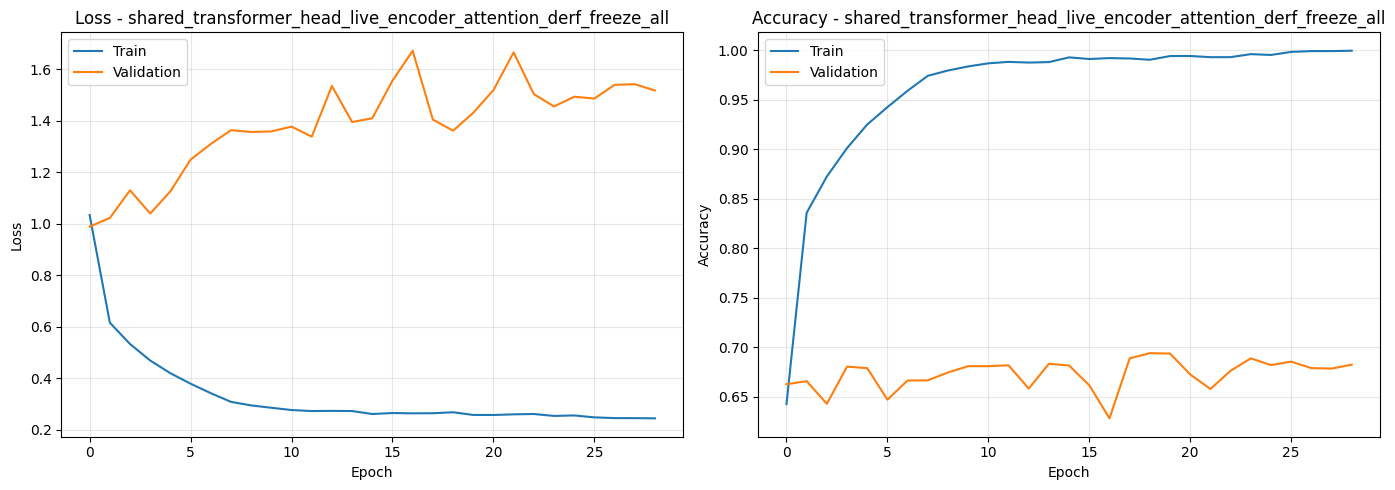

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'Loss - {experiment_name}')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'Accuracy - {experiment_name}')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
experiment_curve_path = os.path.join(ckpt_dir, curve_filename)
plt.savefig(experiment_curve_path, dpi=150)
print(f'实验训练曲线已保存至: {experiment_curve_path}')
plt.show()


## 5. 测试集评估

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)

model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for batch in test_loader:
        batch_inputs = move_batch_to_device(batch, device, training_mode)
        logits = forward_model(model, batch_inputs, training_mode)
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = batch_inputs['labels'].cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(labels)

label_ids = list(range(len(EMOTION_LABELS)))
report_text = classification_report(
    all_labels_list,
    all_preds,
    labels=label_ids,
    target_names=EMOTION_LABELS,
    zero_division=0,
)
print(report_text)

cm = confusion_matrix(all_labels_list, all_preds, labels=label_ids)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {experiment_name}')
plt.tight_layout()
experiment_cm_path = os.path.join(ckpt_dir, cm_filename)
plt.savefig(experiment_cm_path, dpi=150)
print(f'实验混淆矩阵已保存至: {experiment_cm_path}')
plt.show()

summary = {
    'experiment_name': experiment_name,
    'variant': model.variant,
    'training_mode': training_mode,
    'split_meta': split_meta,
    'norm': model.shared_config.get('norm'),
    'pooling': model.shared_config.get('pooling'),
    'freeze_strategy': model.shared_config.get('freeze_strategy'),
    'epochs_ran': int(len(history['val_loss'])),
    'best_metric': best_metric_label,
    'best_epoch': int(best_epoch),
    'selected_val_acc': float(best_selected_metrics['acc']),
    'selected_val_macro_f1': float(best_selected_metrics['macro_f1']),
    'selected_val_uar': float(best_selected_metrics['uar']),
    'selected_val_loss': float(best_val_loss_at_best),
    'best_val_loss': float(np.min(history['val_loss'])),
    'best_val_acc': float(np.max(history['val_acc'])),
    'best_val_macro_f1': float(np.max(history['val_macro_f1'])),
    'best_val_uar': float(np.max(history['val_uar'])),
    'test_acc': float(accuracy_score(all_labels_list, all_preds)),
    'macro_f1': float(f1_score(all_labels_list, all_preds, average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(all_labels_list, all_preds, average='weighted', zero_division=0)),
    'uar': float(recall_score(all_labels_list, all_preds, average='macro', zero_division=0)),
    'esd_epoch_cap': int(esd_epoch_cap),
    'raw_train_samples': int(train_n),
    'raw_esd_train_samples': int(raw_esd_train_samples),
    'effective_train_samples_per_epoch': int(train_sampling_meta['effective_train_samples_per_epoch']),
    'effective_esd_samples_per_epoch': int(train_sampling_meta['effective_esd_samples_per_epoch']),
    'checkpoint_filename': checkpoint_filename,
    'history_filename': history_filename,
}
summary_path = os.path.join(ckpt_dir, summary_filename)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('实验摘要:')
print(summary)
print(f'实验摘要已保存至: {summary_path}')


## 6. 跨架构对比

对比 `CNN+BiLSTM+Attention`（传统基线）与当前 `Whisper+Transformer Emotion Head` 配置的验证集表现；在默认配置下，这一节对应 `Derf` 主线。


当前共享模型对比实验: shared_transformer_head_live_encoder_attention_derf_freeze_all
已加载: emotion_history.npz (48 epochs)
已加载: shared_transformer_head_live_encoder_attention_derf_freeze_all_history.npz (29 epochs)


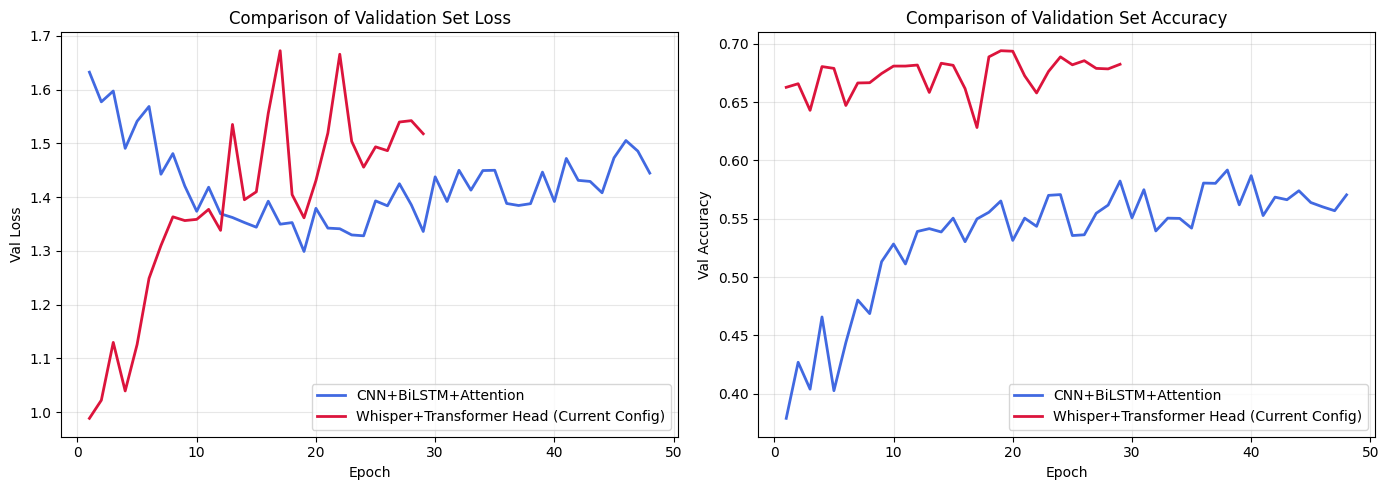



+-------------------------------------------+-----------------+----------------+
| 模型                                      |   Best Val Loss | Best Val Acc   |
+===========================================+=================+================+
| CNN+BiLSTM+Attention                      |          1.2989 | 59.17%         |
+-------------------------------------------+-----------------+----------------+
| Whisper+Transformer Head (Current Config) |          0.9887 | 69.40%         |
+-------------------------------------------+-----------------+----------------+


In [8]:
from tabulate import tabulate

ckpt_dir = cfg['paths']['checkpoints']
shared_cfg = cfg['shared_model']
current_shared_experiment = build_experiment_name(
    shared_cfg['variant'],
    shared_cfg.get('training_mode', 'cached_pooled'),
    shared_cfg,
)
current_shared_label = 'Whisper+Transformer Head (Current Config)'
print(f'当前共享模型对比实验: {current_shared_experiment}')

# 两个模型的 history 文件
MODEL_HISTORY = {
    'CNN+BiLSTM+Attention': 'emotion_history.npz',
    current_shared_label: f'{current_shared_experiment}_history.npz',
}
MODEL_COLORS = {
    'CNN+BiLSTM+Attention': '#4169E1',
    current_shared_label: '#DC143C',
}

# 加载 history
loaded = {}
for name, fname in MODEL_HISTORY.items():
    path = os.path.join(ckpt_dir, fname)
    if os.path.isfile(path):
        loaded[name] = dict(np.load(path))
        print(f'已加载: {fname} ({len(loaded[name]["val_loss"])} epochs)')
    else:
        print(f'未找到: {fname}，跳过 {name}')

if len(loaded) == 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for name, h in loaded.items():
        color = MODEL_COLORS[name]
        epochs_range = range(1, len(h['val_loss']) + 1)
        ax1.plot(epochs_range, h['val_loss'], label=name, color=color, linewidth=2)
        ax2.plot(epochs_range, h['val_acc'], label=name, color=color, linewidth=2)

    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
    ax1.set_title('Comparison of Validation Set Loss')
    ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
    ax2.set_title('Comparison of Validation Set Accuracy')
    ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(ckpt_dir, 'model_comparison.png'), dpi=150)
    plt.show()
    print('\n')
    
    table_data = []
    for name, h in loaded.items():
        best_loss = float(np.min(h['val_loss']))
        best_acc  = float(np.max(h['val_acc']))
        table_data.append([name, f"{best_loss:.4f}", f"{best_acc:.2%}"])

    print(tabulate(table_data, headers=["模型", "Best Val Loss", "Best Val Acc"], tablefmt="grid"))
else:
    print(f'\n只找到 {len(loaded)} 个模型的历史，需要两个才能对比。')
    print('请先运行 03_train_emotion.ipynb 训练 CNN 模型。')


## 7. 归一化消融对比

在保持 `variant=transformer_head`、`training_mode=cached_sequence`、`pooling=attention`、`freeze_strategy=freeze_all` 不变时，对比 `Derf / DyT / LayerNorm` 三种配置。


In [ ]:
from tabulate import tabulate

def load_experiment_group(experiment_stems, ckpt_dir):
    loaded = {}
    for display_name, stem in experiment_stems.items():
        history_path = os.path.join(ckpt_dir, f'{stem}_history.npz')
        summary_path = os.path.join(ckpt_dir, f'{stem}_summary.json')
        if not os.path.isfile(history_path):
            print(f'未找到 history: {history_path}，跳过 {display_name}')
            continue
        history = dict(np.load(history_path))
        summary = None
        if os.path.isfile(summary_path):
            with open(summary_path, 'r', encoding='utf-8') as f:
                summary = json.load(f)
        else:
            print(f'未找到 summary: {summary_path}，将只绘制曲线，不汇总测试指标。')
        loaded[display_name] = {
            'history': history,
            'summary': summary,
        }
        print(f'已加载: {display_name} <- {stem}')
    return loaded


def plot_ablation_group(experiment_stems, ckpt_dir, figure_name, title_prefix):
    loaded = load_experiment_group(experiment_stems, ckpt_dir)
    if len(loaded) < 2:
        print(f'\n只找到 {len(loaded)} 个实验结果，至少需要 2 个才能对比。')
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    color_cycle = ['#DC143C', '#1E90FF', '#228B22', '#FF8C00', '#8B008B']

    for idx, (name, data) in enumerate(loaded.items()):
        h = data['history']
        epochs_range = range(1, len(h['val_loss']) + 1)
        color = color_cycle[idx % len(color_cycle)]
        ax1.plot(epochs_range, h['val_loss'], label=name, color=color, linewidth=2)
        ax2.plot(epochs_range, h['val_acc'], label=name, color=color, linewidth=2)

    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
    ax1.set_title(f'{title_prefix} - Validation Loss')
    ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
    ax2.set_title(f'{title_prefix} - Validation Accuracy')
    ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    output_path = os.path.join(ckpt_dir, figure_name)
    plt.savefig(output_path, dpi=150)
    plt.show()
    print(f'图像已保存至: {output_path}')

    summaries = {name: data['summary'] for name, data in loaded.items() if data['summary'] is not None}
    if summaries:
        headers = ["实验", "Best Val Loss", "Best Val Acc", "Selected Val UAR", "Test Acc", "Macro F1", "Weighted F1", "UAR"]
        table_data = []
        for name, summary in summaries.items():
            row = [
                name,
                summary.get("best_val_loss", float("nan")),
                summary.get("best_val_acc", float("nan")),
                summary.get("selected_val_uar", summary.get("best_val_uar", float("nan"))),
                summary.get("test_acc", float("nan")),
                summary.get("macro_f1", float("nan")),
                summary.get("weighted_f1", float("nan")),
                summary.get("uar", float("nan"))
            ]
            table_data.append(row)
        floatfmt = ["", ".4f", ".2%", ".2%", ".2%", ".4f", ".4f", ".4f"]
        print(tabulate(table_data, headers=headers, floatfmt=floatfmt, tablefmt="grid"))
    else:
        print('\n当前只找到 history 文件，尚未找到 summary 文件，因此无法汇总测试指标。')

def build_transformer_experiment_stem(norm_name, freeze_name, training_mode, pooling='attention'):
    cfg_stub = {
        'pooling': pooling,
        'norm': norm_name,
        'freeze_strategy': freeze_name,
    }
    return build_experiment_name('transformer_head', training_mode, cfg_stub)


NORM_ABLATION = {
    'Derf': build_transformer_experiment_stem('derf', 'freeze_all', 'cached_sequence'),
    'DyT': build_transformer_experiment_stem('dyt', 'freeze_all', 'cached_sequence'),
    'LayerNorm': build_transformer_experiment_stem('layernorm', 'freeze_all', 'cached_sequence'),
}

plot_ablation_group(
    NORM_ABLATION,
    ckpt_dir=ckpt_dir,
    figure_name='shared_norm_ablation.png',
    title_prefix='Normalization Ablation',
)


## 8. 冻结策略消融对比

在保持 `variant=transformer_head`、`training_mode=live_encoder`、`pooling=attention`、`norm=derf` 不变时，对比 `freeze_all` 与 `unfreeze_last_2`。


已加载: Derf + freeze_all <- shared_transformer_head_live_encoder_attention_derf_freeze_all
已加载: Derf + unfreeze_last_2 <- shared_transformer_head_live_encoder_attention_derf_unfreeze_last_2


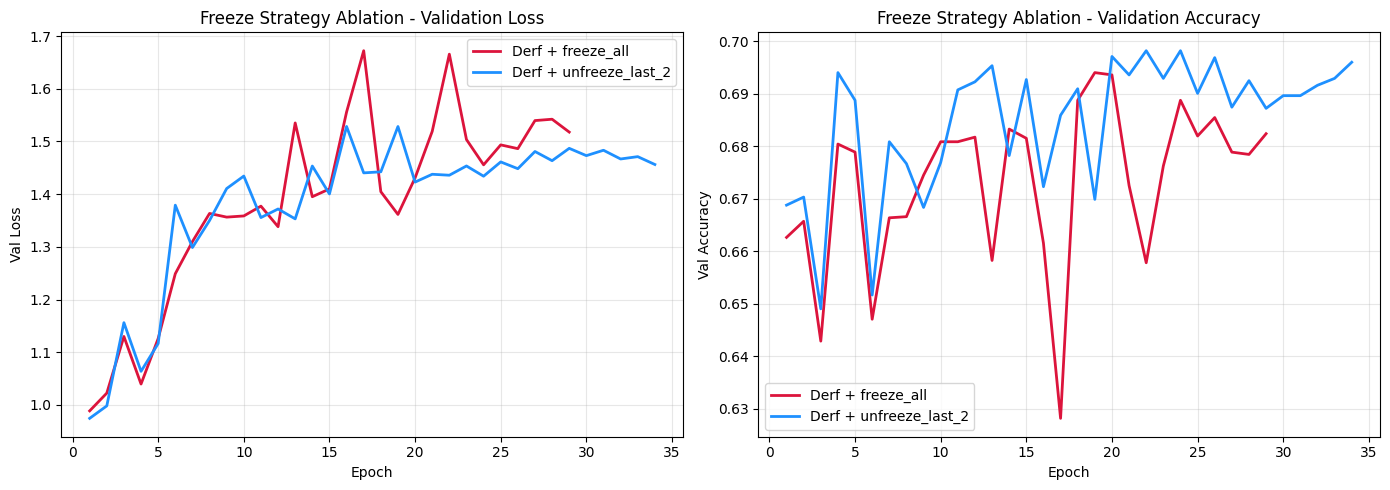

图像已保存至: checkpoints/shared_freeze_ablation.png
+------------------------+-----------------+----------------+------------+------------+---------------+--------+
| 实验                   |   Best Val Loss |   Best Val Acc |   Test Acc |   Macro F1 |   Weighted F1 |    UAR |
+========================+=================+================+============+============+===============+========+
| Derf + freeze_all      |          0.9887 |         69.40% |     73.51% |     0.7058 |        0.7315 | 0.7049 |
+------------------------+-----------------+----------------+------------+------------+---------------+--------+
| Derf + unfreeze_last_2 |          0.9745 |         69.82% |     73.56% |     0.7110 |        0.7276 | 0.7221 |
+------------------------+-----------------+----------------+------------+------------+---------------+--------+


In [10]:
FREEZE_ABLATION = {
    'Derf + freeze_all': build_transformer_experiment_stem('derf', 'freeze_all', 'live_encoder'),
    'Derf + unfreeze_last_2': build_transformer_experiment_stem('derf', 'unfreeze_last_2', 'live_encoder'),
}

plot_ablation_group(
    FREEZE_ABLATION,
    ckpt_dir=ckpt_dir,
    figure_name='shared_freeze_ablation.png',
    title_prefix='Freeze Strategy Ablation',
)
